# EduPro Data Analytics Project

In [1]:
import pandas as pd
print("hello jupyter")

hello jupyter


In [2]:
import pandas as pd
print("Pandas is working")

Pandas is working


## Data Loading

In [3]:
excel_file=pd.ExcelFile("data/EduPro.xlsx")
print(excel_file.sheet_names)

['Users', 'Teachers', 'Courses', 'Transactions']


In [4]:
import pandas as pd
users=pd.read_excel("data/EduPro.xlsx", sheet_name='Users')
users.head()




,UserID,UserName,Age,Gender,Email
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com
1,U00002,angela22,29,Female,hallrandy@hotmail.com
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com
3,U00004,fthornton,23,Female,christensencatherine@outlook.com
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com


In [5]:
courses =pd.read_excel("data/EduPro.xlsx", sheet_name='Courses')
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [6]:
transactions=pd.read_excel("data/EduPro.xlsx", sheet_name='Transactions')
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [7]:
teachers=pd.read_excel("data/EduPro.xlsx", sheet_name='Teachers')
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [8]:
print("Users:",users.shape)
print("Courses:",courses.shape)
print("Transactions:",transactions.shape)
print("Teachers:",teachers.shape)



Users: (3000, 5)
Courses: (60, 8)
Transactions: (10000, 7)
Teachers: (60, 7)


## Data Quality Checks

In [9]:
print(users.isnull().sum())
print(courses.isnull().sum())
print(teachers.isnull().sum())
print(transactions.isnull().sum())


UserID      0
UserName    0
Age         0
Gender      0
Email       0
dtype: int64
CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64
TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64
TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64


In [10]:
print("Users:",users.duplicated().sum())
print("Courses:",courses.duplicated().sum())
print("Teachers:",teachers.duplicated().sum())
print("Transactions:",transactions.duplicated().sum())

Users: 0
Courses: 0
Teachers: 0
Transactions: 0


In [11]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   UserID    3000 non-null   str  
 1   UserName  3000 non-null   str  
 2   Age       3000 non-null   int64
 3   Gender    3000 non-null   str  
 4   Email     3000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 239.5 KB


## Age Distribution Analysis

In [12]:
users["Age"].describe()

count    3000.000000
mean       24.974333
std         6.046475
min        15.000000
25%        20.000000
50%        25.000000
75%        30.000000
max        35.000000
Name: Age, dtype: float64

In [13]:
users["AgeGroup"]=pd.cut(
    users["Age"],bins=(14,17,25,35),labels=["15-17","18-25","26-35"])
users.head()

,UserID,UserName,Age,Gender,Email,AgeGroup
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-17
1,U00002,angela22,29,Female,hallrandy@hotmail.com,26-35
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,26-35
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,18-25
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,18-25


In [14]:
users["AgeGroup"].value_counts().sort_index()

AgeGroup
15-17     433
18-25    1121
26-35    1446
Name: count, dtype: int64

In [15]:
age_percentage=(users["AgeGroup"].value_counts(normalize=True).sort_index()*100)
users["AgePercentage"]=users["AgeGroup"].map(age_percentage)
users.head()
users.drop(columns=["AgePercentage"], inplace=True)
users.columns

Index(['UserID', 'UserName', 'Age', 'Gender', 'Email', 'AgeGroup'], dtype='str')

In [16]:
age_distribution=pd.DataFrame({
    "Count": users["AgeGroup"].value_counts().sort_index(),
    "Percentage":users["AgeGroup"].value_counts(normalize=True).sort_index()*100
})
age_distribution

,Count,Percentage
AgeGroup,,
15-17,433,14.433333
18-25,1121,37.366667
26-35,1446,48.200000


In [17]:
users.head()

,UserID,UserName,Age,Gender,Email,AgeGroup
0,U00001,wilsonjordan,15,Male,patricia27@hotmail.com,15-17
1,U00002,angela22,29,Female,hallrandy@hotmail.com,26-35
2,U00003,morrisonamanda,33,Female,ganderson@yahoo.com,26-35
3,U00004,fthornton,23,Female,christensencatherine@outlook.com,18-25
4,U00005,fostergeoffrey,21,Male,karenfuentes@yahoo.com,18-25


## Gender Distribution Analysis

In [18]:
users["Gender"].value_counts()

Gender
Female    1520
Male      1480
Name: count, dtype: int64

In [19]:
gender_distribution=pd.DataFrame({
    "Count":users["Gender"].value_counts(),
    "Percentage":users["Gender"].value_counts(normalize=True)*100,
})
gender_distribution

,Count,Percentage
Gender,,
Female,1520,50.666667
Male,1480,49.333333


## Course Analysis

In [20]:
courses.head()

,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


In [21]:
courses["CourseCategory"].value_counts()

CourseCategory
Programming                5
Design                     5
Business                   5
Marketing                  5
Data Science               5
Machine Learning           5
Cybersecurity              5
Project Management         5
Finance                    5
Artificial Intelligence    5
Web Development            5
Digital Marketing          5
Name: count, dtype: int64

### Course Type Distribution

In [22]:
courses["CourseType"].value_counts()

CourseType
Free    38
Paid    22
Name: count, dtype: int64

In [23]:
course_type_distribution=pd.DataFrame({
    "Count":courses["CourseType"].value_counts(),
    "Percentage":courses["CourseType"].value_counts(normalize=True) * 100
})
course_type_distribution


,Count,Percentage
CourseType,,
Free,38,63.333333
Paid,22,36.666667


### Course Level Distribution

In [24]:
courses["CourseLevel"].value_counts()

CourseLevel
Beginner        21
Advanced        21
Intermediate    18
Name: count, dtype: int64

In [25]:
course_level_distribution=pd.DataFrame({
    "Count":courses["CourseLevel"].value_counts(),
    "Percentage":courses["CourseLevel"].value_counts(normalize=True) * 100
})
course_level_distribution[ "Percentage"]= course_level_distribution[ "Percentage"].round(2)
course_level_distribution

,Count,Percentage
CourseLevel,,
Beginner,21,35.0
Advanced,21,35.0
Intermediate,18,30.0


## Teacher Analysis

In [26]:
teachers.head()

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


### Teacher Expertise Analysis

In [27]:
teachers["Expertise"].value_counts()

Expertise
Digital Marketing          11
Cybersecurity               9
Finance                     6
Artificial Intelligence     6
Machine Learning            5
Data Science                5
Project Management          5
Web Development             5
Design                      4
Business                    2
Marketing                   1
Programming                 1
Name: count, dtype: int64

In [28]:
teachers_expertise_distribution=pd.DataFrame({
    "Count":teachers["Expertise"].value_counts(),
    "Percentage":teachers["Expertise"].value_counts(normalize=True) *100
})
teachers_expertise_distribution["Percentage"] = teachers_expertise_distribution["Percentage"].round(2)
teachers_expertise_distribution["Percentage"]

Expertise
Digital Marketing          18.33
Cybersecurity              15.00
Finance                    10.00
Artificial Intelligence    10.00
Machine Learning            8.33
Data Science                8.33
Project Management          8.33
Web Development             8.33
Design                      6.67
Business                    3.33
Marketing                   1.67
Programming                 1.67
Name: Percentage, dtype: float64

### Teacher Rating Analysis

In [29]:
teachers["TeacherRating"].describe()

count    60.000000
mean      3.125000
std       0.949797
min       1.050000
25%       2.487500
50%       3.275000
75%       3.827500
max       4.970000
Name: TeacherRating, dtype: float64

## Transaction Analysis

In [30]:
transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [31]:
transactions["PaymentMethod"].value_counts()

PaymentMethod
PayPal           3389
Credit Card      3333
Bank Transfer    3278
Name: count, dtype: int64

In [32]:
transactions["Amount"].describe()

count    10000.000000
mean        91.132347
std        152.063524
min          0.000000
25%          0.000000
50%          0.000000
75%        119.040000
max        490.900000
Name: Amount, dtype: float64

In [33]:
transactions["Amount"].value_counts()

Amount
0.00      6403
299.57     192
57.32      178
327.99     174
490.90     174
487.92     173
37.89      171
0.78       171
285.05     168
346.71     167
89.59      166
117.68     166
53.86      166
472.28     164
415.51     163
119.04     161
342.61     158
276.37     156
326.02     151
394.26     150
212.39     148
248.10     140
177.34     140
Name: count, dtype: int64

# Business Question Analysis

In [34]:
import pandas as pd
user_transactions=pd.merge(
    transactions,
    users,
    on="UserID"

)

In [35]:
user_transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,Email,AgeGroup
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,26-35
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,26-35
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,26-35
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,christensencatherine@outlook.com,18-25
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,christensencatherine@outlook.com,18-25


In [36]:
user_transactions.shape

(10000, 12)

## Age Group  Activity Analysis

In [37]:
user_transactions["AgeGroup"].value_counts()

AgeGroup
26-35    4799
18-25    3732
15-17    1469
Name: count, dtype: int64

## Question 1 : Which Age Groups Are More Active on the Platform

In [38]:
age_activity = pd.DataFrame({
    "Enrollments": user_transactions["AgeGroup"].value_counts(),
    "Percentage":user_transactions["AgeGroup"].value_counts(normalize=True)* 100
})
age_activity["Percentage"] =age_activity["Percentage"].round(2)
age_activity

,Enrollments,Percentage
AgeGroup,,
26-35,4799,47.99
18-25,3732,37.32
15-17,1469,14.69


## Question 2 : How Do Enrollment Patterns Differ by Gender

In [39]:
user_transactions["Gender"].value_counts()

Gender
Female    5078
Male      4922
Name: count, dtype: int64

In [40]:
gender_activity = pd.DataFrame({
    "Enrollments": user_transactions["Gender"].value_counts(),
    "Percentage":user_transactions["Gender"].value_counts(normalize=True)* 100
})
gender_activity["Percentage"] =gender_activity["Percentage"].round(2)
gender_activity

,Enrollments,Percentage
Gender,,
Female,5078,50.78
Male,4922,49.22


## Question 3 : What Course Categories Are Preferred by Different Learner Segments?

In [41]:
user_course_data = pd.merge(
    user_transactions,
    courses,
    on="CourseID"
)

In [42]:
user_course_data.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,Email,AgeGroup,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,26-35,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,26-35,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,26-35,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,christensencatherine@outlook.com,18-25,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,christensencatherine@outlook.com,18-25,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [43]:
user_course_data.shape

(10000, 19)

### Age Group vs Course Category Analysis

In [44]:
age_category_analysis=pd.crosstab(
    user_course_data["AgeGroup"],
    user_course_data["CourseCategory"]
)
age_category_analysis

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
AgeGroup,,,,,,,,,,,,
15-17,129,120,121,114,120,127,136,120,126,109,115,132
18-25,317,307,307,343,311,296,297,305,313,305,296,335
26-35,383,406,391,459,396,385,431,394,367,392,418,377


### Key Observation
Data Science is the most preferred category among learners aged 18-25 and 26-35

In [45]:
age_category_percentage=pd.crosstab(
    user_course_data["AgeGroup"],
    user_course_data["CourseCategory"],
    normalize="index"
    ) * 100
age_category_percentage.round(2)

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
AgeGroup,,,,,,,,,,,,
15-17,8.78,8.17,8.24,7.76,8.17,8.65,9.26,8.17,8.58,7.42,7.83,8.99
18-25,8.49,8.23,8.23,9.19,8.33,7.93,7.96,8.17,8.39,8.17,7.93,8.98
26-35,7.98,8.46,8.15,9.56,8.25,8.02,8.98,8.21,7.65,8.17,8.71,7.86


## Question 4 : Are Beginner,Intermediate,or Advanced Courses More Popular among Specific Age Groups?

### Age Group vs Course level Analysis

In [46]:
age_level_analysis=pd.crosstab(
    user_course_data["AgeGroup"],
    user_course_data["CourseLevel"],
    
) 
age_level_analysis

CourseLevel,Advanced,Beginner,Intermediate
AgeGroup,,,
15-17,534,501,434
18-25,1300,1345,1087
26-35,1641,1727,1431


In [47]:
age_level_percentage=pd.crosstab(
    user_course_data["AgeGroup"],
    user_course_data["CourseLevel"],
    normalize="index"
) * 100
age_level_percentage.round(2)

CourseLevel,Advanced,Beginner,Intermediate
AgeGroup,,,
15-17,36.35,34.10,29.54
18-25,34.83,36.04,29.13
26-35,34.19,35.99,29.82


### Are There Gender-Based Differences in Course Selection?

In [48]:
gender_based_difference=pd.crosstab(
    user_course_data["Gender"],
    user_course_data["CourseCategory"]
)
gender_based_difference

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
Gender,,,,,,,,,,,,
Female,413,418,430,479,424,417,451,403,385,420,425,413
Male,416,415,389,437,403,391,413,416,421,386,404,431


In [49]:
user_course_data["CourseCategory"].value_counts()

CourseCategory
Data Science               916
Finance                    864
Web Development            844
Business                   833
Project Management         829
Artificial Intelligence    829
Design                     827
Cybersecurity              819
Machine Learning           819
Digital Marketing          808
Marketing                  806
Programming                806
Name: count, dtype: int64

### Do Beginners Prefer Certain Course Types or Levels?

In [50]:
pd.crosstab(
    user_course_data["CourseLevel"],
    user_course_data["CourseType"]
)

CourseType,Free,Paid
CourseLevel,,
Advanced,2005,1470
Beginner,2395,1178
Intermediate,2003,949


# KPI Analysis

## Total Enrollments

In [51]:
total_enrollments=len(user_transactions)
print(total_enrollments)

10000


## Course Level Preference Distribution

In [52]:
user_course_data["CourseLevel"].value_counts()

CourseLevel
Beginner        3573
Advanced        3475
Intermediate    2952
Name: count, dtype: int64

# Chart Analysis

## Age Distribution

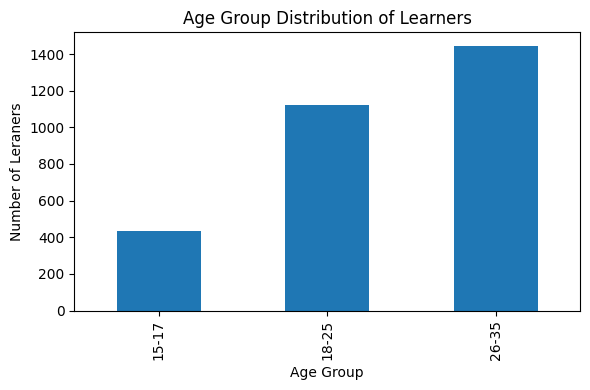

In [53]:
import matplotlib.pyplot as plt
age_counts=users["AgeGroup"].value_counts().sort_index()
plt.figure(figsize=(6,4))
age_counts.plot(kind="bar")
plt.title("Age Group Distribution of Learners")
plt.xlabel("Age Group")
plt.ylabel("Number of Leraners")
plt.tight_layout()
plt.show()


## Course Enrollments vs Age Group

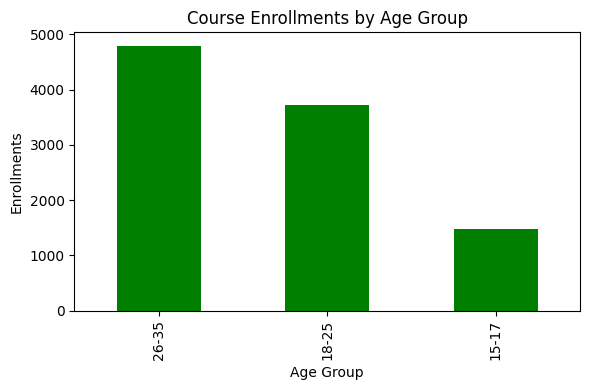

In [54]:
age_activity["Enrollments"].plot(kind="bar",figsize=(6,4),color="green")
plt.title("Course Enrollments by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Enrollments")
plt.tight_layout()
plt.show()

## Gender Perticipation Ratio


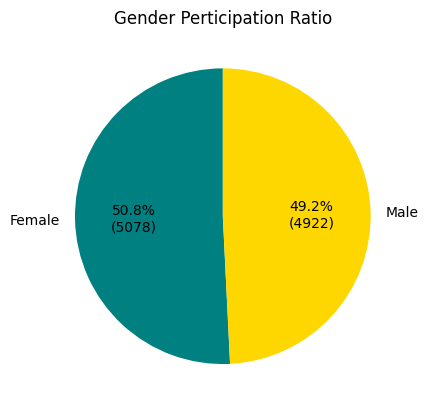

In [55]:
values=gender_activity["Enrollments"]
def show_value_and_percent(pct):
    total=sum(values)
    count=int(round(pct*total/100))
    return f"{pct:.1f}%\n({count})"
plt.Figure(figsize=(6,6))
plt.pie(values,
        labels=gender_activity.index,
        autopct=show_value_and_percent,
        startangle=90,
        colors=["teal","gold"])
plt.title("Gender Perticipation Ratio")
plt.show()

## Course Category vs Enrollments

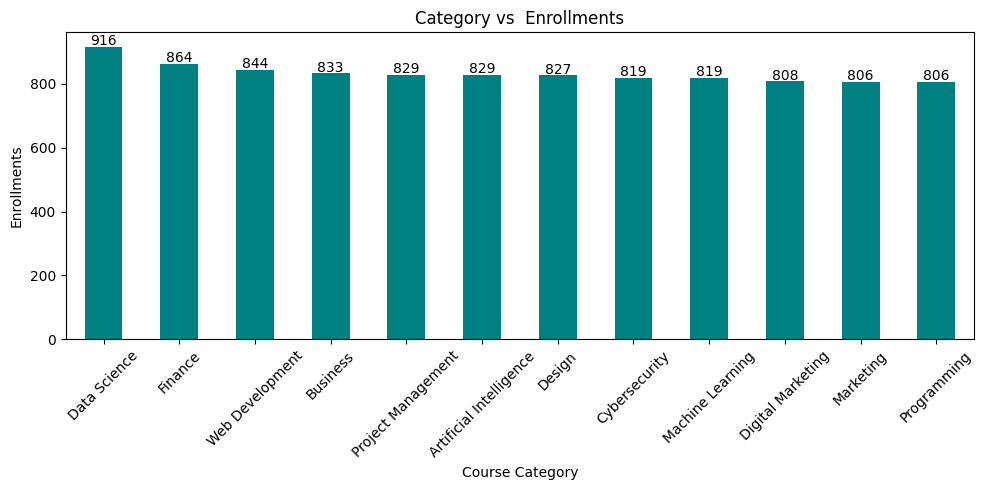

In [56]:
category_enrollment=user_course_data["CourseCategory"].value_counts()
ax=category_enrollment.plot(
    kind="bar",
    figsize=(10,5),color="teal"
)
for i,v in enumerate(category_enrollment):
    ax.text(i,v+5, str(v),ha="center")
plt.title("Category vs  Enrollments")
plt.xlabel("Course Category")
plt.ylabel("Enrollments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Course Category vs Gender Distribution

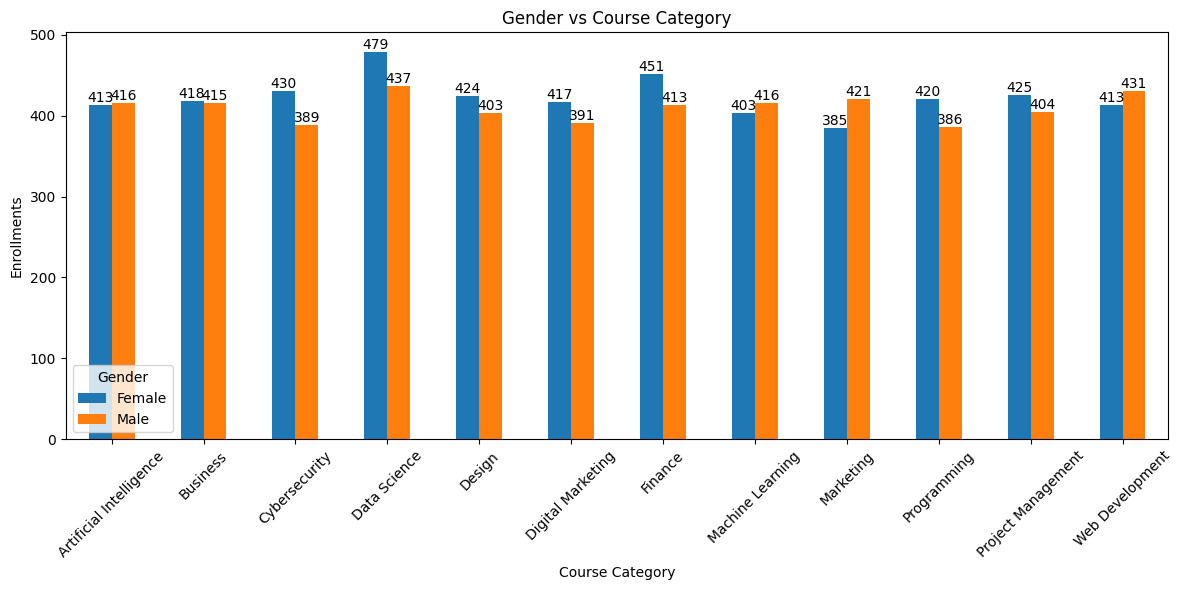

In [57]:
ax=gender_based_difference.T.plot(kind="bar",figsize=(12,6))
for container in ax.containers:
    ax.bar_label(container,fmt="%d")
plt.title("Gender vs Course Category")
plt.xlabel("Course Category")
plt.ylabel("Enrollments")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

## Course Level Preference Distribution

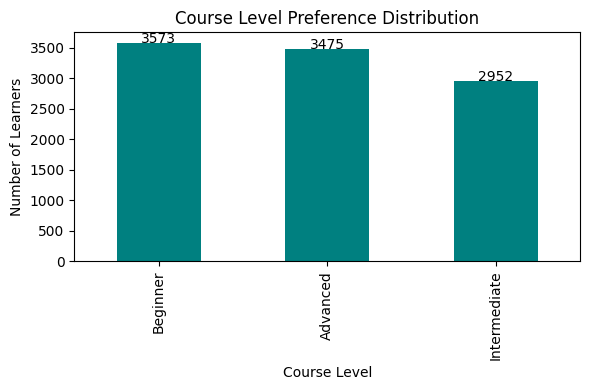

In [58]:
course_level_counts=user_course_data["CourseLevel"].value_counts()
ax=course_level_counts.plot(kind="bar",figsize=(6,4),color="teal")

for i,v in enumerate(course_level_counts):
    ax.text(i,v+5, str(v),ha="center")
plt.title("Course Level Preference Distribution")
plt.xlabel("Course Level")
plt.ylabel("Number of Learners")
plt.tight_layout()
plt.show()

## Course Type vs Course Level

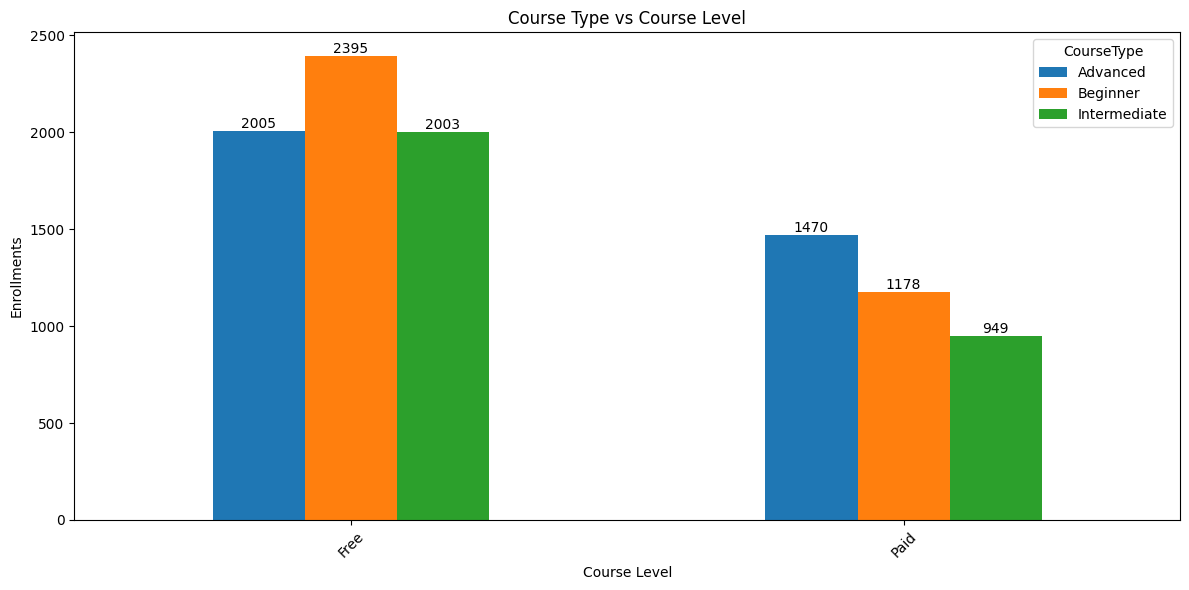

In [59]:
CourseType_wise_CourseLevel=pd.crosstab(
    user_course_data["CourseLevel"],
    user_course_data["CourseType"]
)
ax=CourseType_wise_CourseLevel.T.plot(kind="bar",figsize=(12,6))
for container in ax.containers:
    ax.bar_label(container,fmt="%d")
plt.title("Course Type vs Course Level")
plt.xlabel("Course Level")
plt.ylabel("Enrollments")
plt.xticks(rotation=45)
plt.legend(title="CourseType")
plt.tight_layout()
plt.show()

